In [51]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")


In [52]:
data = pd.read_csv("../data/data.csv")
genre_data = pd.read_csv("../data/data_by_genres.csv")
year_data = pd.read_csv("../data/data_by_year.csv")

In [55]:
data_1980 = data[data["year"] >= 1980].copy()

In [56]:
data_1980["year"].min()

np.int64(1980)

In [57]:
print("Original dataset:", data.shape)
print("1980+ dataset:", data_1980.shape)

Original dataset: (170653, 19)
1980+ dataset: (81201, 19)


In [59]:
data_1980["danceability"]

11606     0.310
11607     0.774
11608     0.933
11609     0.751
11610     0.532
          ...  
170648    0.786
170649    0.717
170650    0.634
170651    0.671
170652    0.856
Name: danceability, Length: 81201, dtype: float64

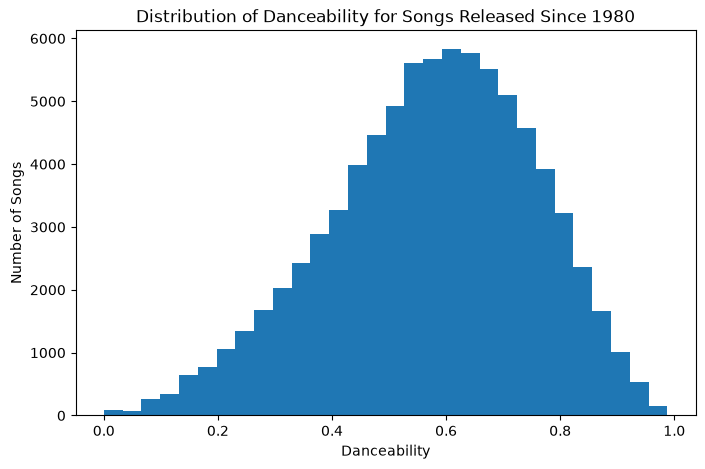

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(data_1980["danceability"], bins=30)

plt.xlabel("Danceability")
plt.ylabel("Number of Songs")
plt.title("Distribution of Danceability for Songs Released Since 1980")

plt.show()

In [61]:
data_1980["danceability"].describe()

count    81201.000000
mean         0.574019
std          0.178623
min          0.000000
25%          0.457000
50%          0.588000
75%          0.706000
max          0.988000
Name: danceability, dtype: float64

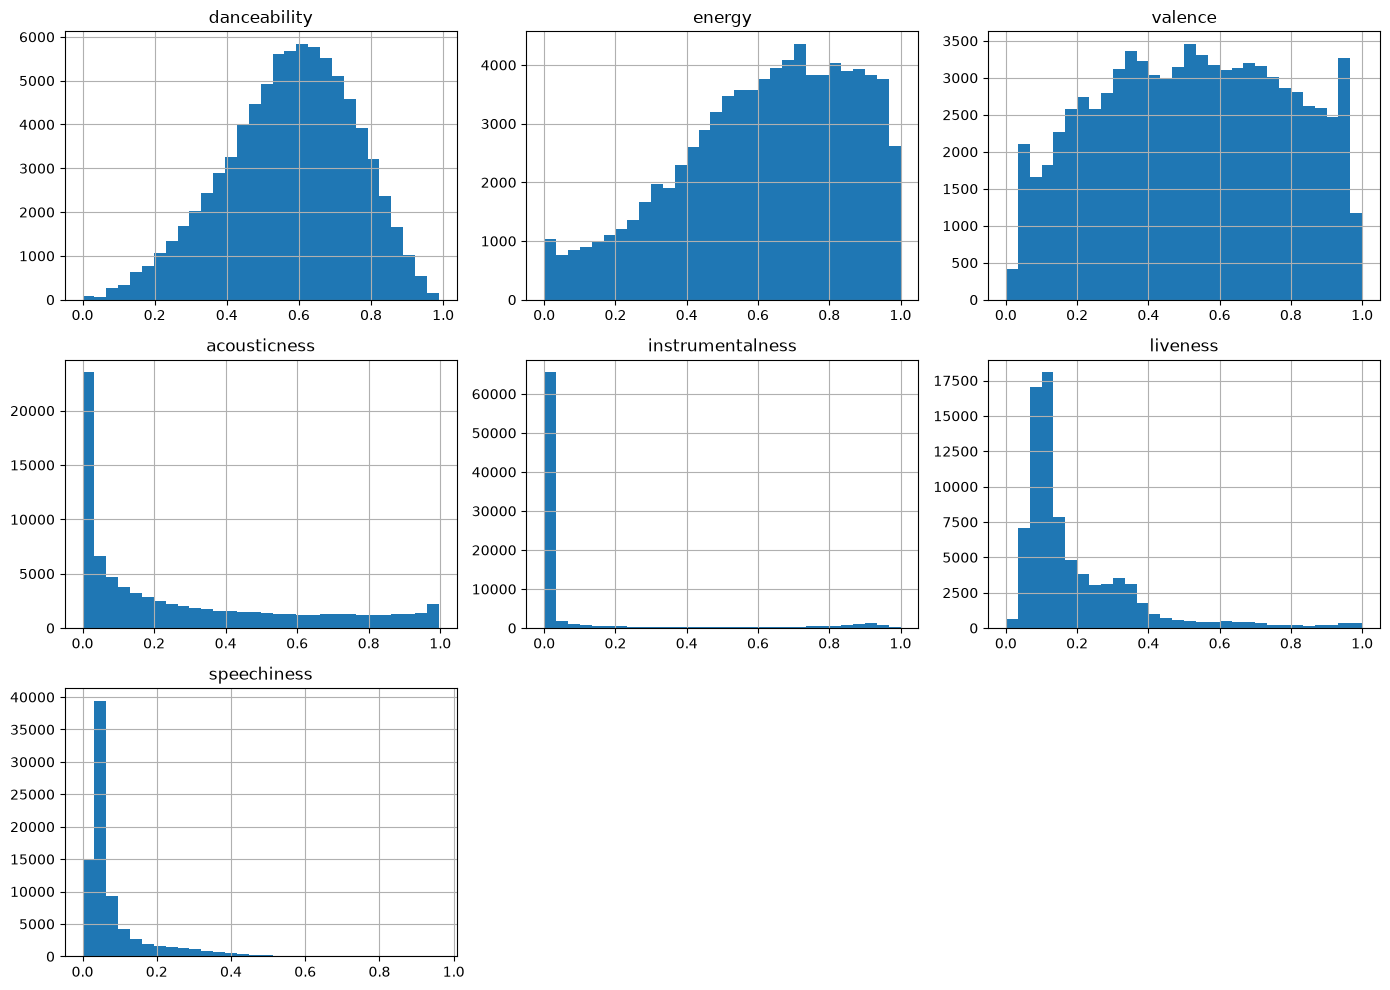

In [62]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness"
]

data_1980[audio_features].hist(
    bins=30,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

In [63]:
data_1980.isnull().sum()

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

In [64]:
data_1980.duplicated().sum()

np.int64(0)

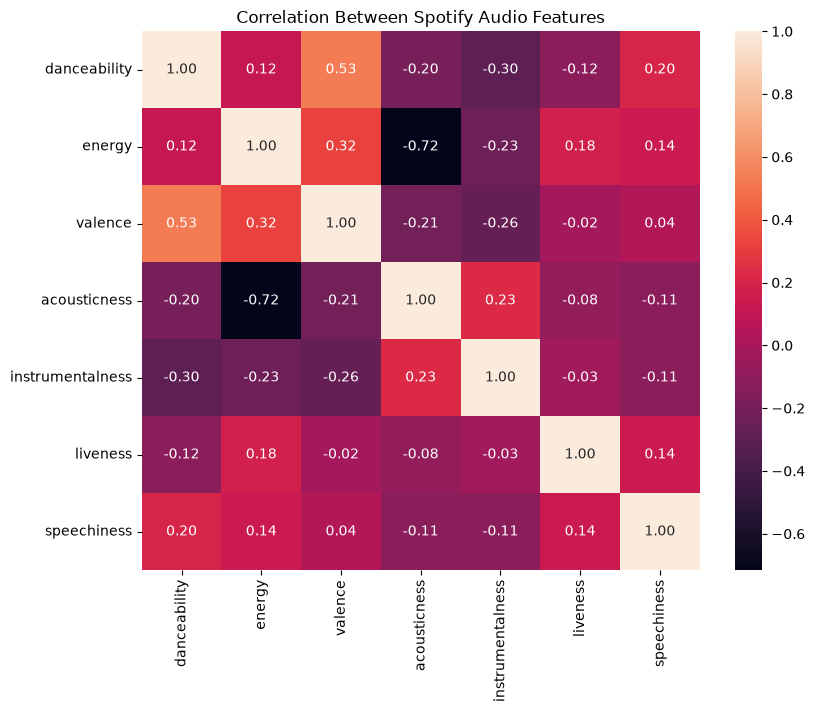

In [67]:
correlation = data_1980[audio_features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Spotify Audio Features")

plt.show()

In [68]:
danceability_by_year = (
    data_1980
    .groupby("year")["danceability"]
    .mean()
)

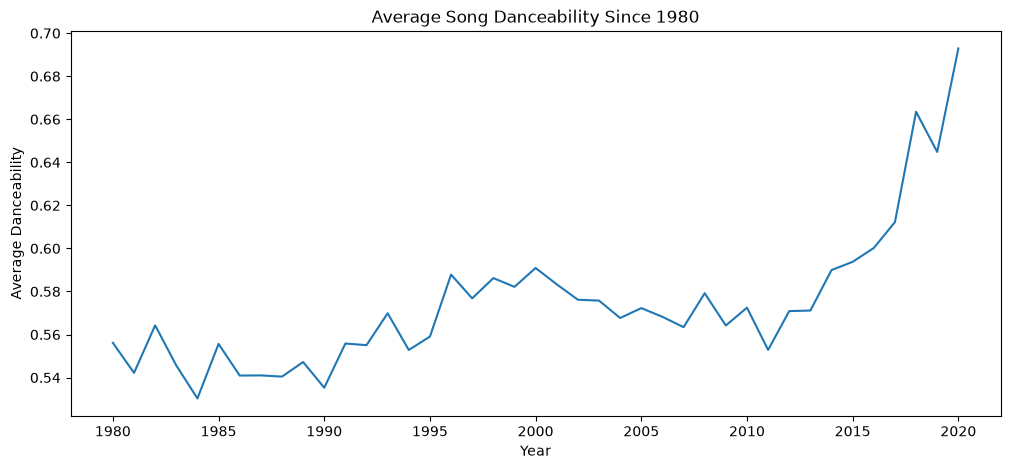

In [69]:
plt.figure(figsize=(12, 5))

plt.plot(
    danceability_by_year.index,
    danceability_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Average Danceability")
plt.title("Average Song Danceability Since 1980")

plt.show()

In [70]:
model_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

In [71]:
songs_per_year = data_1980.groupby("year").size()

songs_per_year

year
1980    1950
1981    2000
1982    2000
1983    2000
1984    2000
1985    2000
1986    2000
1987    1950
1988    1950
1989    2000
1990    2000
1991    1950
1992    2000
1993    2000
1994    2000
1995    2000
1996    2000
1997    2000
1998    2000
1999    1951
2000    1956
2001    2005
2002    2000
2003    1954
2004    1966
2005    1950
2006    1950
2007    1950
2008    1955
2009    1960
2010    2016
2011    2017
2012    1945
2013    1976
2014    2005
2015    1974
2016    1797
2017    1992
2018    2103
2019    1949
2020    2030
dtype: int64

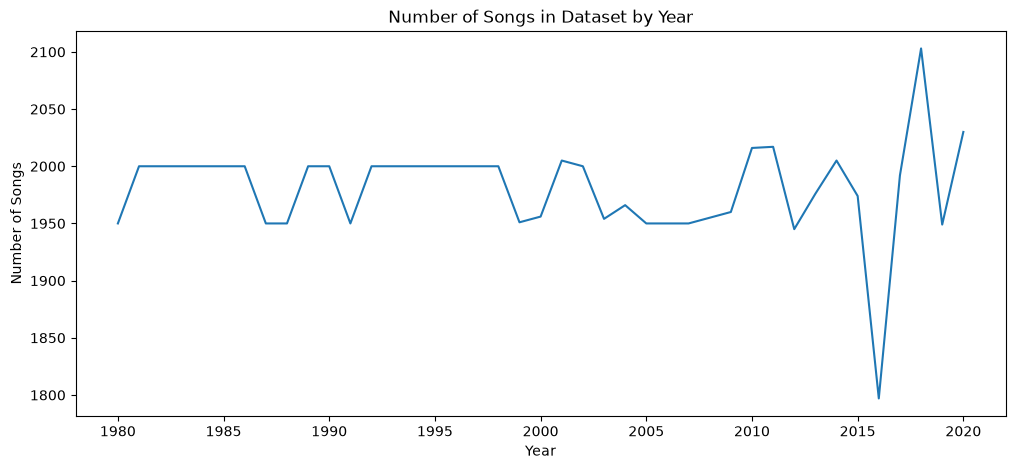

In [72]:
plt.figure(figsize=(12, 5))

plt.plot(
    songs_per_year.index,
    songs_per_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.title("Number of Songs in Dataset by Year")

plt.show()

In [73]:
trend_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness"
]

yearly_features = (
    data_1980
    .groupby("year")[trend_features]
    .mean()
)

In [74]:
yearly_features.head()

,danceability,energy,valence,acousticness
year,,,,
1980,0.556152,0.597777,0.598058,0.284955
1981,0.542185,0.599383,0.582952,0.301204
1982,0.564259,0.590919,0.586438,0.289580
1983,0.545629,0.601425,0.572120,0.294778
1984,0.530309,0.591092,0.551639,0.287710


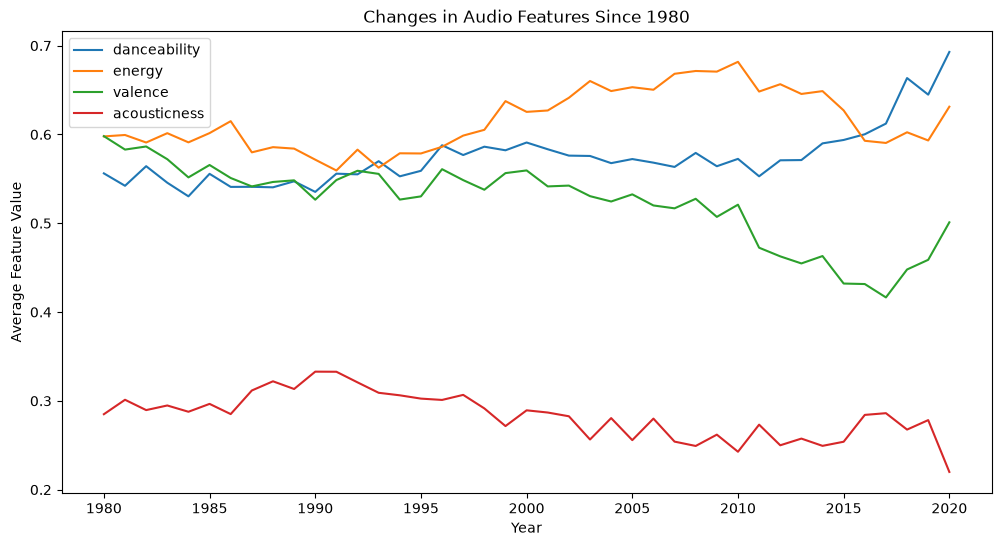

In [163]:
plt.figure(figsize=(12, 6))

for feature in trend_features:
    plt.plot(
        yearly_features.index,
        yearly_features[feature],
        label=feature
    )

plt.xlabel("Year")
plt.ylabel("Average Feature Value")
plt.title("Changes in Audio Features Since 1980")
plt.legend()
plt.savefig(
    "../images/audio_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

correlation_matrix = data_1980[audio_features].corr()

In [78]:
recommendation_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

In [79]:
data_model = data_1980.dropna(
    subset=recommendation_features
).copy()

In [80]:
print(data_1980.shape)
print(data_model.shape)

(81201, 19)
(81201, 19)


In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
scaler = StandardScaler()

In [83]:
scaled_features = scaler.fit_transform(
    data_model[recommendation_features]
)

scaled_features.shape

(81201, 9)

In [132]:
favorite_titles = [
    "Billie Jean",
    "Sunflower",
    "Sanguine Paradise",
    "Space Cadet",
    "20 Min",
    "Congratulations"
]

data_model[
    data_model["name"].isin(favorite_titles)
][["name", "artists", "year"]]

,name,artists,year
396,Billie Jean,['Michael Jackson'],1982
7079,Congratulations,"['Post Malone', 'Quavo']",2016
7274,20 Min,['Lil Uzi Vert'],2017
7319,Sunflower,['Rex Orange County'],2017
7750,Sanguine Paradise,['Lil Uzi Vert'],2019
10846,Space Cadet,['Kyuss'],1994
13951,Congratulations,['MGMT'],2010
18918,Billie Jean,['Michael Jackson'],1995
22299,Billie Jean,['The Civil Wars'],2012
25441,Congratulations,['Traveling Wilburys'],1988


In [133]:
data_model[
    data_model["name"].str.contains(
        "20 Min",
        case=False,
        na=False,
        regex=False
    )
][["name", "artists", "year"]]

,name,artists,year
7274,20 Min,['Lil Uzi Vert'],2017
62601,20 Min - Chopped and Screwed,['DJ Purpberry'],2018


In [ ]:
favorite_songs = [
    {"name": "Billie Jean", "artist": "Michael Jackson"},
    {"name": "Sunflower", "artist": "Post Malone"},
    {"name": "Happier", "artist": "Marshmello"},
    {"name": "Sanguine Paradise", "artist": "Lil Uzi Vert"},
    {"name": "Congratulations", "artist": "Post Malone"},
    {"name": "Space Cadet", "artist": "Metro Boomin"}
]

In [134]:
favorite_rows = []

for song in favorite_songs:
    matches = data_model[
        (data_model["name"].str.lower() == song["name"].lower()) &
        (data_model["artists"].str.contains(
            song["artist"],
            case=False,
            na=False,
            regex=False
        ))
    ]

    favorite_rows.append(matches)

favorite_data = pd.concat(favorite_rows)

favorite_data[
    ["name", "artists", "year"] + recommendation_features
]

,name,artists,year,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness
7829,Hear Me Calling,['Juice WRLD'],2019,0.699,0.687,0.499,0.3080,0.000036,0.121,0.1060,88.932,-3.997
7499,Happier,"['Marshmello', 'Bastille']",2018,0.687,0.792,0.671,0.1910,0.000000,0.167,0.0452,100.015,-2.749
7750,Sanguine Paradise,['Lil Uzi Vert'],2019,0.729,0.603,0.207,0.0948,0.000000,0.113,0.0666,134.972,-6.736
7079,Congratulations,"['Post Malone', 'Quavo']",2016,0.630,0.804,0.492,0.2150,0.000000,0.253,0.0363,123.146,-4.183


In [135]:
data_model = data_model.drop_duplicates(
    subset=["name", "artists", "year"]
).reset_index(drop=True)

In [136]:
data_model.duplicated(
    subset=["name", "artists", "year"]
).sum()

np.int64(0)

In [137]:
data_model = (
    data_1980
    .dropna(subset=recommendation_features)
    .drop_duplicates(subset=["name", "artists", "year"])
    .reset_index(drop=True)
    .copy()
)


In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    data_model[recommendation_features]
)

In [139]:
favorite_data[
    ["name", "artists", "year"]
]

,name,artists,year
7829,Hear Me Calling,['Juice WRLD'],2019
7499,Happier,"['Marshmello', 'Bastille']",2018
7750,Sanguine Paradise,['Lil Uzi Vert'],2019
7079,Congratulations,"['Post Malone', 'Quavo']",2016


In [140]:
favorite_indices = favorite_data.index

In [141]:
favorite_scaled = scaler.transform(
    favorite_data[recommendation_features]
)

In [142]:
user_profile = favorite_scaled.mean(axis=0)
print(user_profile)

[ 0.63276918  0.44455372 -0.21600389 -0.27518852 -0.40037097 -0.19150428
 -0.20510782 -0.2959926   0.91918466]


In [143]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    user_profile.reshape(1, -1),
    scaled_features
)[0]

In [144]:
results = data_model.copy()

results["similarity"] = similarities

In [145]:
results[
    ["name", "artists", "year", "similarity"]
].sort_values(
    "similarity",
    ascending=False
).head(20)

,name,artists,year,similarity
62795,All the Time,['Zara Larsson'],2019,0.958827
7523,The Middle,"['Zedd', 'Maren Morris', 'Grey']",2018,0.957265
30877,Solo Dance,['Martin Jensen'],2016,0.954107
76972,Nillili Mambo,['Block B'],2012,0.944154
70433,Pump It Up - Radio Edit,"['Geo Da Silva', 'Fizo Faouez']",2018,0.942849
23534,Trap (feat. Lil Baby),"['SAINt JHN', 'Lil Baby']",2019,0.942408
23821,Baby,['Madison Beer'],2020,0.938285
30532,Fun (feat. Chris Brown),"['Pitbull', 'Chris Brown']",2014,0.938161
22824,Ghost,['Ella Henderson'],2015,0.936843
29642,Paparazzi,['Lady Gaga'],2009,0.936566


In [146]:
def create_song_key(df):
    return (
        df["name"].str.lower().str.strip()
        + "|"
        + df["artists"].astype(str).str.lower().str.strip()
    )

In [147]:
favorite_keys = set(create_song_key(favorite_data))

results["song_key"] = create_song_key(results)

In [148]:
recommendations = results[
    ~results["song_key"].isin(favorite_keys)
]

In [149]:
recommendations = (
    recommendations
    .sort_values("similarity", ascending=False)
    .head(10)
)

recommendations

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,...,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,similarity,song_key
62795,0.500,2019,0.1800,['Zara Larsson'],0.665,228112,0.799,0,3OTSBoYKO7HzGVj8Bu2OH9,0.000000,...,0.1250,-2.868,0,All the Time,69,2019-06-21,0.0617,101.976,0.958827,all the time|['zara larsson']
7523,0.437,2018,0.1710,"['Zedd', 'Maren Morris', 'Grey']",0.753,184732,0.657,0,09IStsImFySgyp0pIQdqAc,0.000000,...,0.1120,-3.061,1,The Middle,82,2018-01-23,0.0449,107.010,0.957265,"the middle|['zedd', 'maren morris', 'grey']"
30877,0.403,2016,0.0485,['Martin Jensen'],0.746,174933,0.846,0,3hRi7ubt1NhroxTrdnjn4w,0.000000,...,0.1950,-2.432,1,Solo Dance,57,2016-11-04,0.0480,114.955,0.954107,solo dance|['martin jensen']
76972,0.512,2012,0.0119,['Block B'],0.755,205322,0.839,0,4fZYGHiRcKxwVSnF498uaE,0.000000,...,0.0905,-2.693,0,Nillili Mambo,50,2012-10-17,0.0538,109.938,0.944154,nillili mambo|['block b']
70433,0.559,2018,0.0636,"['Geo Da Silva', 'Fizo Faouez']",0.773,192755,0.821,0,5Ix2p6ky1lBVT9iprKls1h,0.000000,...,0.0878,-2.677,0,Pump It Up - Radio Edit,0,2018-12-26,0.0584,107.968,0.942849,"pump it up - radio edit|['geo da silva', 'fizo..."
23534,0.349,2019,0.0849,"['SAINt JHN', 'Lil Baby']",0.791,184699,0.839,1,2Y8hY4rRRQQjdaZkkwzpd9,0.000000,...,0.1930,-2.887,1,Trap (feat. Lil Baby),71,2019-08-23,0.0424,116.991,0.942408,"trap (feat. lil baby)|['saint jhn', 'lil baby']"
23821,0.452,2020,0.0799,['Madison Beer'],0.705,207734,0.707,0,7LjEQ8GsQiUNVakV6TZI0e,0.000000,...,0.1490,-5.174,1,Baby,79,2020-08-21,0.0534,117.974,0.938285,baby|['madison beer']
30532,0.547,2014,0.1560,"['Pitbull', 'Chris Brown']",0.793,202307,0.774,0,6Zo3wgDE076K2AuiGZF3CS,0.000000,...,0.1930,-3.667,0,Fun (feat. Chris Brown),61,2014-11-21,0.0478,113.967,0.938161,"fun (feat. chris brown)|['pitbull', 'chris bro..."
22824,0.468,2015,0.0457,['Ella Henderson'],0.680,213213,0.840,0,4z7gh3aIZV9arbL9jJSc5J,0.000008,...,0.1430,-3.823,1,Ghost,57,2015-01-13,0.0415,104.985,0.936843,ghost|['ella henderson']
29642,0.397,2009,0.1130,['Lady Gaga'],0.762,208307,0.692,0,0uNMe6UEqe9uGazPgUGnLD,0.000000,...,0.0940,-3.973,0,Paparazzi,54,2009-11-05,0.0438,114.906,0.936566,paparazzi|['lady gaga']


In [150]:
def recommend_songs(
    favorite_data,
    data_model,
    scaler,
    scaled_features,
    recommendation_features,
    n=10
):

    favorite_scaled = scaler.transform(
        favorite_data[recommendation_features]
    )

    user_profile = favorite_scaled.mean(axis=0)

    similarities = cosine_similarity(
        user_profile.reshape(1, -1),
        scaled_features
    )[0]

    results = data_model.copy()
    results["similarity"] = similarities

    favorite_keys = set(create_song_key(favorite_data))
    results["song_key"] = create_song_key(results)

    results = results[
        ~results["song_key"].isin(favorite_keys)
    ]

    return (
        results
        .sort_values("similarity", ascending=False)
        .head(n)[
            ["name", "artists", "year", "similarity"]
        ]
    )

In [109]:
test_song = favorite_data.iloc[[0]]

training_favorites = favorite_data.drop(
    index=test_song.index
)

In [151]:
training_scaled = scaler.transform(
    training_favorites[recommendation_features]
)

test_profile = training_scaled.mean(axis=0)

In [152]:
test_similarities = cosine_similarity(
    test_profile.reshape(1, -1),
    scaled_features
)[0]

In [154]:
evaluation_results = data_model.copy()

evaluation_results["similarity"] = test_similarities

evaluation_results = evaluation_results.sort_values(
    "similarity",
    ascending=False
).reset_index(drop=True)

evaluation_results

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,similarity
0,0.86000,1995,0.35000,['Lonestar'],0.7410,173600,0.68300,0,2KgsImShtnuBYfKVgfbAuy,0.000000,5,0.0604,-5.866,0,No News,48,1995-10-09,0.0285,116.301,0.994915
1,0.82900,2004,0.36100,['Shivaree'],0.7430,243777,0.67400,0,5jQPDVjgSGnNYl8G3H3qul,0.000089,2,0.0696,-7.683,1,Goodnight Moon,55,2004-04-13,0.0323,112.906,0.980564
2,0.85100,1992,0.39200,['Ricardo Arjona'],0.7660,207013,0.71900,0,4TR6e2sBy2PzTnfu6MnLFD,0.010200,2,0.0519,-6.480,1,Mujeres,62,1992,0.0353,105.678,0.977753
3,0.85900,1981,0.27200,['France Gall'],0.7230,274627,0.67900,0,51BbACodhBnd9lBs2TI0YT,0.000211,7,0.0640,-6.774,0,Résiste - Remasterisé en 2004,53,1981,0.0307,117.392,0.976850
4,0.81600,2006,0.31300,['Old Crow Medicine Show'],0.6980,226893,0.63800,0,7m1TJgrWNy72WgKmK51QgJ,0.000003,4,0.0937,-5.968,0,Down Home Girl,45,2006-08-29,0.0371,111.205,0.974918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78581,0.02990,2012,0.00583,['Nature Sounds'],0.1580,1943484,0.57400,0,0mbGHKzGjJx1omRaqNgwmB,0.579000,8,0.3470,-25.155,1,Rain With Light Thunderstorm,47,2012-02-12,0.1790,110.004,-0.859313
78582,0.01360,2014,0.00312,['Nature Sounds'],0.0642,197112,0.30800,0,1ESl3PuNrAqlJ67ZxJIzz4,0.000000,1,0.6040,-17.238,1,Rain: Evening Sleep,48,2014-01-01,0.1940,77.757,-0.867841
78583,0.11500,2003,0.10600,['Radiohead'],0.4400,212027,0.60900,0,2q4zYomFf4ZVrEOr1aXj6l,0.110000,4,0.3820,-13.370,0,The Gloaming,43,2003,0.2780,133.243,-0.878019
78584,0.23300,2007,0.00494,['Daft Punk'],0.5200,329653,0.54500,0,4IdiGMOzEYXOh2897XOV8i,0.285000,11,0.4640,-12.670,0,Touch It / Technologic,50,2007-11-16,0.1580,121.780,-0.878064


In [157]:
test_name = test_song.iloc[0]["name"]
test_artist = test_song.iloc[0]["artists"]

held_out_result = evaluation_results[
    (evaluation_results["name"] == test_name) &
    (evaluation_results["artists"] == test_artist)
]

held_out_result


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,similarity
14564,0.499,2019,0.308,['Juice WRLD'],0.699,189977,0.687,1,13ZyrkCDmRz5xY3seuAWYk,0.000036,7,0.121,-3.997,0,Hear Me Calling,76,2019-03-08,0.106,88.932,0.522337


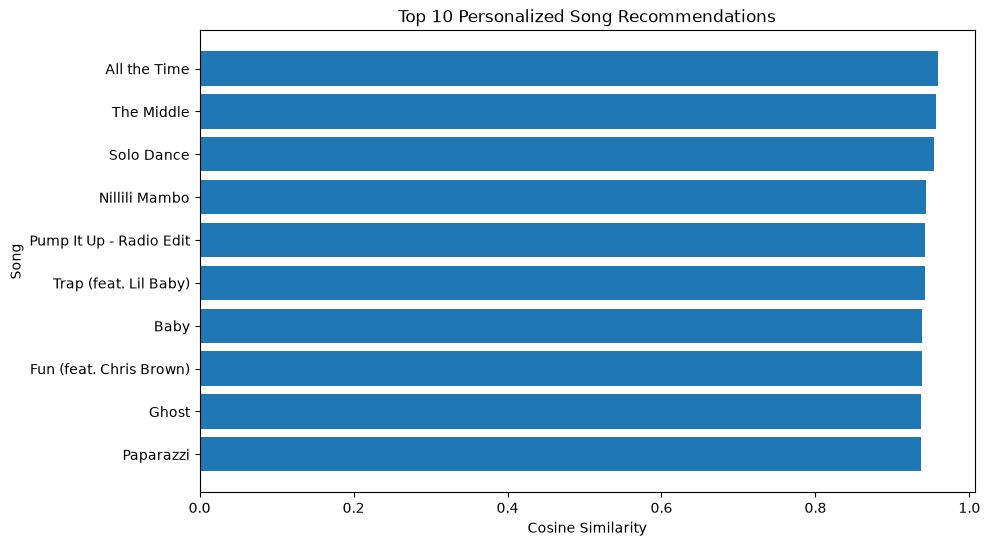

In [162]:
plt.figure(figsize=(10, 6))

plt.barh(
    recommendations["name"],
    recommendations["similarity"]
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Song")
plt.title("Top 10 Personalized Song Recommendations")
plt.savefig(
    "../images/top_recommendationd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.gca().invert_yaxis()

plt.show()

In [158]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

song_pca = pca.fit_transform(scaled_features)

song_pca

array([[ 1.10742678, -1.28440549],
       [ 0.24823183,  1.83624019],
       [ 0.94585854,  1.55176316],
       ...,
       [ 1.65822284,  0.0066237 ],
       [ 0.80321637, -0.78634187],
       [ 1.45434207,  1.18665404]], shape=(78586, 2))

In [159]:
pca_df = pd.DataFrame(
    song_pca,
    columns=["PC1", "PC2"]
)

pca_df["name"] = data_model["name"]
pca_df["artists"] = data_model["artists"]

pca_df

,PC1,PC2,name,artists
0,1.107427,-1.284405,Back In Black,['AC/DC']
1,0.248232,1.836240,Wonderful Christmastime - Edited Version / Rem...,['Paul McCartney']
2,0.945859,1.551763,Another One Bites The Dust - Remastered 2011,['Queen']
3,0.399789,1.255471,You Make My Dreams (Come True),['Daryl Hall & John Oates']
4,1.481045,-0.678930,You Shook Me All Night Long,['AC/DC']
...,...,...,...,...
78581,1.638817,0.825662,China,"['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna..."
78582,1.305121,0.635578,Halloweenie III: Seven Days,['Ashnikko']
78583,1.658223,0.006624,AYA,['MAMAMOO']
78584,0.803216,-0.786342,Darkness,['Eminem']


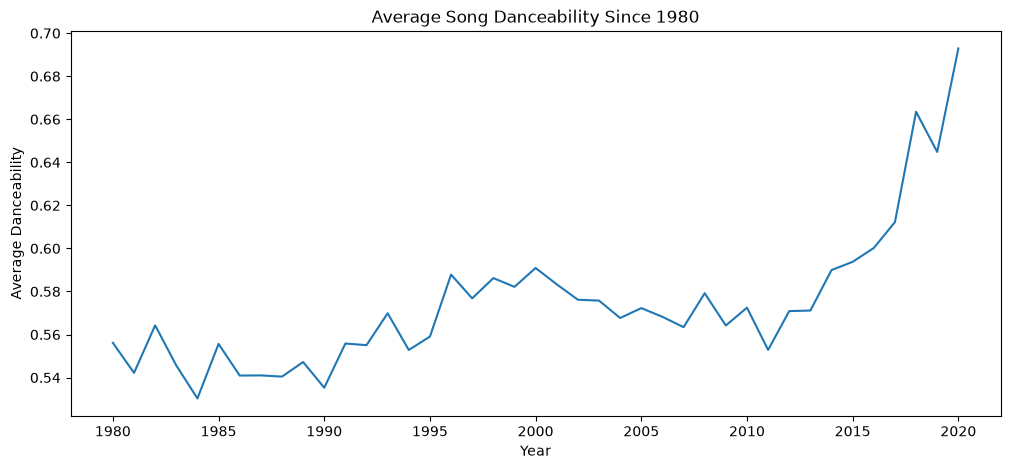

In [160]:
plt.figure(figsize=(12, 5))

plt.plot(
    danceability_by_year.index,
    danceability_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Average Danceability")
plt.title("Average Song Danceability Since 1980")

plt.savefig(
    "../images/danceability_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [161]:
plt.savefig(
    "../images/audio_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../images/top_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../images/pca_song_space.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>